In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mdtraj as md
import glob
import os
import pickle

xtcs = np.array(glob.glob('Mutant Substitution files/ag_sub_tau5/ag_sub_tau5_xtc/*.xtc'))
pdbs = np.array(glob.glob('Mutant Substitution files/ag_sub_tau5/ag_sub_tau5_pdb/*.pdb'))

wt_dir = "/Users/markhsia/robustelli_lab/WT ensembles"

wt_xtc_file = glob.glob(f"{wt_dir}/tau5_wt_ensemble.xtc")[0]
wt_pdb_file = glob.glob(f"{wt_dir}/tau5_wt_ensemble.pdb")[0]

In [2]:
def plot_rg_with_wt(mutant_name, xtcs, pdbs, wt_xtc_file, wt_pdb_file, bin_width=1.0):
    
    # Load WT trajectory
    traj_wt = md.load(wt_xtc_file, top=wt_pdb_file)
    rg_wt = md.compute_rg(traj_wt) * 10.0  # convert to Å

    # Find mutant files
    mutant_xtc_list = [x for x in xtcs if mutant_name in os.path.basename(x)]
    mutant_pdb_list = [p for p in pdbs if mutant_name in os.path.basename(p)]
    
    if not mutant_xtc_list or not mutant_pdb_list:
        raise ValueError(f"Mutant files for '{mutant_name}' not found.")
    
    mutant_xtc_file = mutant_xtc_list[0]
    mutant_pdb_file = mutant_pdb_list[0]

    # Load mutant trajectory
    traj_mut = md.load(mutant_xtc_file, top=mutant_pdb_file)
    rg_mut = md.compute_rg(traj_mut) * 10.0

    # Use shared bins for consistent comparison
    min_rg = min(rg_wt.min(), rg_mut.min())
    max_rg = max(rg_wt.max(), rg_mut.max())
    bins = np.arange(min_rg, max_rg + bin_width, bin_width)
    edges = bins
    centers = 0.5 * (edges[1:] + edges[:-1])

    hist_wt, _ = np.histogram(rg_wt, bins=edges, density=True)
    hist_mut, _ = np.histogram(rg_mut, bins=edges, density=True)

    # Plot WT + mutant on the same figure
    global i

    ax = axes[i]
    ax.plot(centers, hist_wt, label='WT')
    ax.plot(centers, hist_mut, label=mutant_name)

    ax.set_xlabel("Radius of Gyration (Å)")
    ax.set_ylabel("Probability Density")
    ax.set_title(mutant_name)

    i += 1

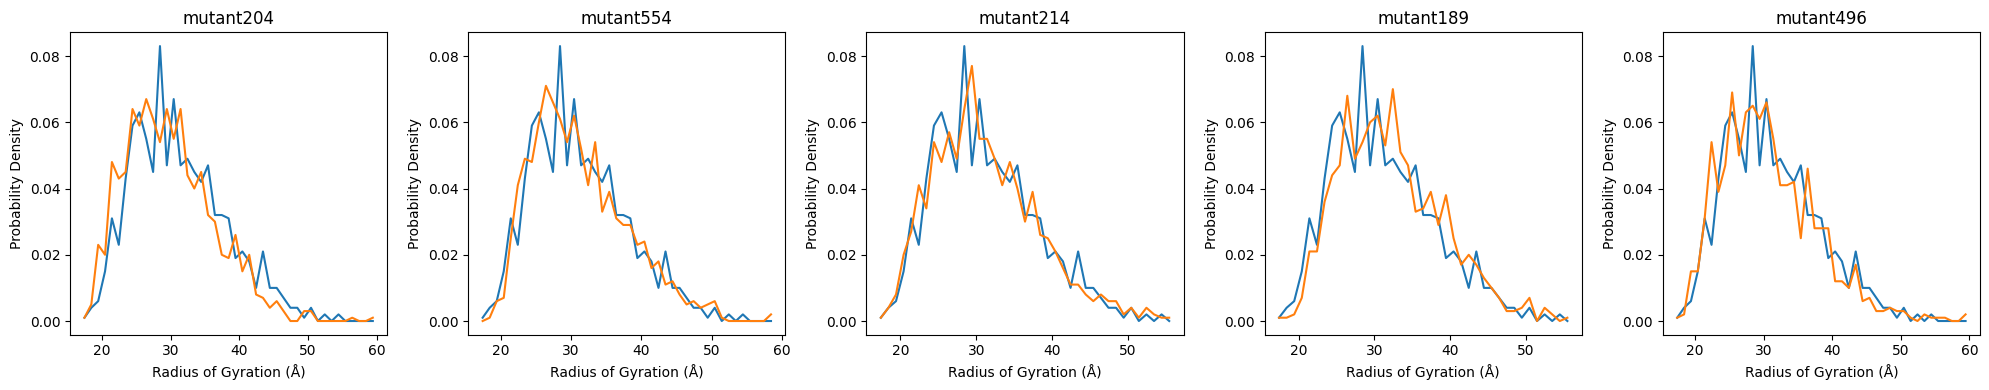

In [8]:
mutants = ["mutant204", "mutant554", "mutant214", "mutant189", "mutant496"]
fig, axes = plt.subplots(1, len(mutants), figsize=(4*len(mutants), 4))

if len(mutants) == 1:
    axes = [axes]

i = 0  # global index
for mutant in mutants:
    plot_rg_with_wt(mutant, xtcs, pdbs, wt_xtc_file, wt_pdb_file)

#axes[5].legend()  # show legend once
plt.tight_layout()
plt.show()